# Representative Subduction Cases in the Fram Strait: Figure Generation
---

### Notebook Purpose
This notebook is a dedicated visualization script designed to generate figures for the manuscript. Rather than acting as a data-processing or calculation pipeline, this notebook assumes all secondary variables have been pre-computed (or are computed while loading the dataset). Its sole purpose is to isolate and plot three specific case studies that represent distinct physical mechanisms of upper-ocean water mass subduction in the Fram Strait.

### Requirements & Input Data Architecture
The plotting loop requires pre-processed outputs partitioned by the model deployment Day of Year (DOY), located on the `/inpath/`:
1. **NetCDF Data (`.nc`):** Containing Lagrangian tracking positions alongside calculated vertical hydrographic profiles (Temperature, Salinity), Mixed Layer Depth (MLD), and (Rossby numbers ($Ro$) is computed during loading from velocity gradients and latitude).
2. **Drifter Index Mapping Spindles (`.csv`):** Matrix keys used to map original larg(er) particle run IDs back to the subset runs with vertical column data, that was only run for individual particles. The mapping is strictly not needed for plotting itself.

### Target Representative Cases
The visualization loop steps through three example drifters selected as structural archetypes for the paper:
* **Drifter 1009 (release DOY 274):** *[e.g., Scenario A: Desinsification]* — Time limits cropped to `2007-12-10` to highlight the descent phase.
* **Drifter 1480 (release DOY 1):** *[e.g., Scenario B: Fast, high Ro descent]* — Time limits cropped to `2007-03-01`.
* **Drifter 1281 (release DOY 1):** *[e.g., Scenario C: Slow Isopycnal descent]* — Time limits cropped to `2007-06-10`.


In [ ]:
# Data handling
import pandas as pd
import xarray as xr
import numpy as np

# Plotting
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib as mpl
import cartopy.crs as ccrs
import cmocean as cmo
import matplotlib.font_manager as fm


plotpath = "/albedo/work/user/quraus001/FESOM_particles/analysis/plots/paper/"

# Custom imports
import sys
sys.path.append('/albedo/work/user/quraus001/FESOM_particles/analysis/functions/')
import particles_loading as pload
import plotting_functions as plf
import wedge_map as wm

from matplotlib.font_manager import FontProperties
font_bold = '/albedo/work/user/quraus001/FESOM_particles/fonts/MYRIADPRO-BOLD.OTF' 
font      = "/albedo/work/user/quraus001/FESOM_particles/fonts/MYRIADPRO-REGULAR.OTF"

In [3]:
inpath = "/albedo/work/user/quraus001/FESOM_particles/result/"
mapping_path = "/albedo/work/user/quraus001/FESOM_particles/input/"

files_dates = ["2026-05-26", "2026-05-26", "2026-05-26", "2026-06-03"]

DS = {}
for doy, date in zip([1, 91, 182, 274], files_dates):

    filename = f"drifter_output_2006-{str(doy).zfill(3)}_lat-76_particles-123_tracking-730d_{date}.nc"
    ds1, STEPS_PER_DAY, DOY, YEAR, release_date = pload.read_particle_data(inpath + filename, calc_column=True)

    # load mapping
    mapping_df = pd.read_csv(mapping_path + f"drifter_idx_mapping_2006-{str(DOY).zfill(3)}_subset.csv")

    # 1. Build your mapping dictionary
    mapping_dict = dict(zip(mapping_df['new_drifter_idx']+1, mapping_df['original_drifter_idx']+1))

    # 2. Map the coordinate using pandas under the hood, then assign it back 
    # This completely replaces the old 'drifter' values with the new mapped values
    ds1 = ds1.assign_coords(drifter=ds1['drifter'].to_series().map(mapping_dict).to_xarray())

    DS[doy] = ds1

Release date: 2006-01-01 00:00:00
 - Day of year: 1
 - Out steps per day: 12


...Calculating column density in chunks:   0%|          | 0/1 [00:00<?, ?it/s]/albedo/home/quraus001/miniforge3/envs/pyfesom_env/lib/python3.10/site-packages/gsw/_wrapped_ufuncs.py:1054: RuntimeWarning: invalid value encountered in ct_from_pt
  return _gsw_ufuncs.ct_from_pt(SA, pt)
...Calculating column density in chunks: 100%|██████████| 1/1 [00:01<00:00,  1.25s/it]


Release date: 2006-04-01 00:00:00
 - Day of year: 91
 - Out steps per day: 12


...Calculating column density in chunks:   0%|          | 0/1 [00:00<?, ?it/s]/albedo/home/quraus001/miniforge3/envs/pyfesom_env/lib/python3.10/site-packages/gsw/_wrapped_ufuncs.py:1054: RuntimeWarning: invalid value encountered in ct_from_pt
  return _gsw_ufuncs.ct_from_pt(SA, pt)
...Calculating column density in chunks: 100%|██████████| 1/1 [00:00<00:00,  2.93it/s]


Release date: 2006-07-01 00:00:00
 - Day of year: 182
 - Out steps per day: 12


...Calculating column density in chunks:   0%|          | 0/1 [00:00<?, ?it/s]/albedo/home/quraus001/miniforge3/envs/pyfesom_env/lib/python3.10/site-packages/gsw/_wrapped_ufuncs.py:1054: RuntimeWarning: invalid value encountered in ct_from_pt
  return _gsw_ufuncs.ct_from_pt(SA, pt)
...Calculating column density in chunks: 100%|██████████| 1/1 [00:00<00:00,  2.14it/s]


Release date: 2006-10-01 00:00:00
 - Day of year: 274
 - Out steps per day: 12


...Calculating column density in chunks:   0%|          | 0/1 [00:00<?, ?it/s]/albedo/home/quraus001/miniforge3/envs/pyfesom_env/lib/python3.10/site-packages/gsw/_wrapped_ufuncs.py:1054: RuntimeWarning: invalid value encountered in ct_from_pt
  return _gsw_ufuncs.ct_from_pt(SA, pt)
...Calculating column density in chunks: 100%|██████████| 1/1 [00:00<00:00,  1.41it/s]


In [ ]:
# Register the custom font file using the global fontManager instance
font_path = "/albedo/work/user/quraus001/FESOM_particles/fonts/MYRIADPRO-REGULAR.OTF"
fm.fontManager.addfont(font_path)  # <-- The correct instance call

# Extract the exact font name registered by Matplotlib
font_name = fm.FontProperties(fname=font_path).get_name()

# Update rcParams globally
plt.rcParams.update({
    'font.family': font_name,  # Sets Myriad Pro globally
    'font.size': 10,          
    'axes.labelsize': 12,     
    'axes.titlesize': 14,     
})

font_prop_bold = FontProperties(fname=font_bold)

Processing Drifter: 390, doy: 274


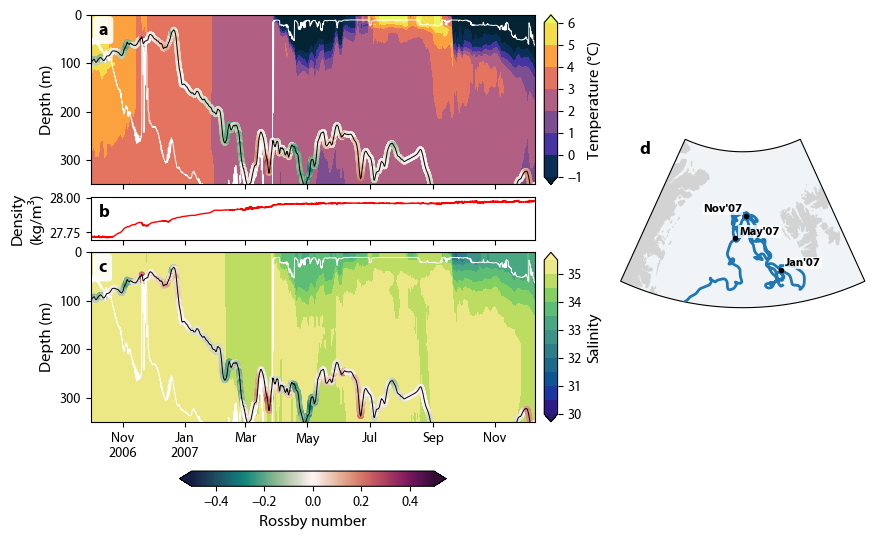

Processing Drifter: 1480, doy: 1


/albedo/home/quraus001/miniforge3/envs/pyfesom_env/lib/python3.10/site-packages/shapely/creation.py:119: RuntimeWarning: invalid value encountered in linestrings
  return lib.linestrings(coords, out=out, **kwargs)


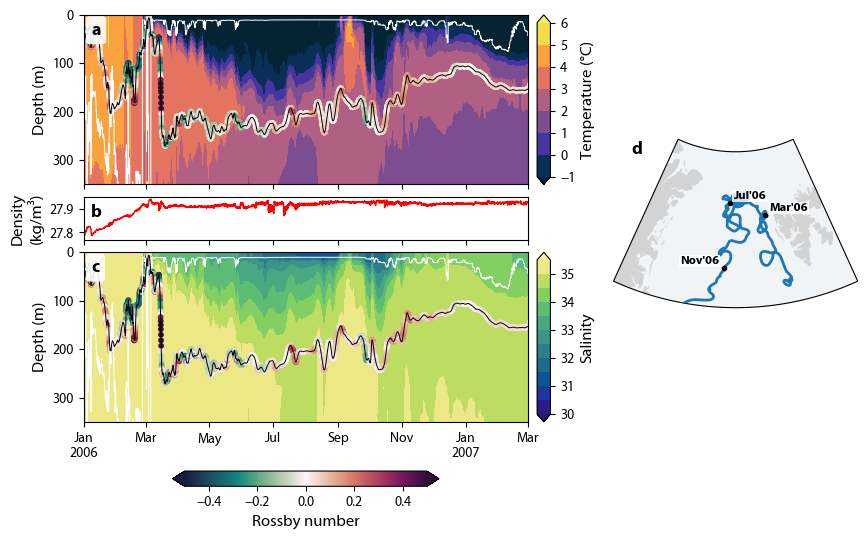

Processing Drifter: 1281, doy: 1


/albedo/home/quraus001/miniforge3/envs/pyfesom_env/lib/python3.10/site-packages/shapely/creation.py:119: RuntimeWarning: invalid value encountered in linestrings
  return lib.linestrings(coords, out=out, **kwargs)


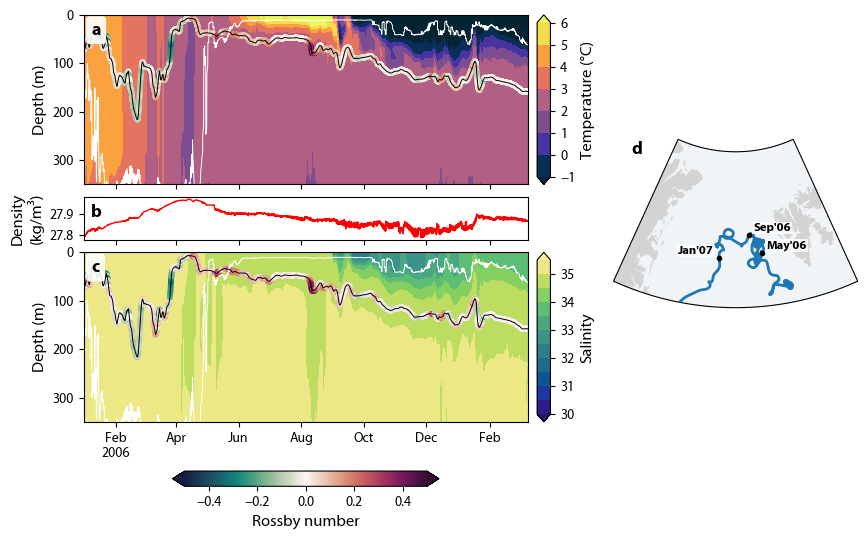

In [ ]:
# --- Configuration Profiles for the Target Drifters ---
selected = [(390, 274), (1480, 1), (1281, 1)] #(1009, 274)
#xlims = ["2007-12-10", "2007-03-01", "2007-06-10"]
xlims = ["2007-12-10", "2007-03-01", "2007-03-10"]


Milestones = [
    ["2007-01-01", "2007-05-01", "2007-11-01"], 
    ["2006-03-01", "2006-07-01", "2006-11-01"], 
    ["2006-05-01", "2006-09-01", "2007-01-01"]
]
Horizontal_alignments = [
    ["left", "left", "right"], 
    ["left", "left", "right"], 
    ["left", "left", "right"]
]


# --- Main Multi-Panel Plot Loop ---
for i, (drifter, doy) in enumerate(selected[:]):
    print(f"Processing Drifter: {drifter}, doy: {doy}")
    ds_drifter = DS[doy].sel(drifter=drifter)
        
    # Balanced publication dimensions (Width=7.5" preserves standard A4 margins)
    fig = plt.figure(figsize=(9, 5.5)) 

    # --- Geometry Grid Layout (GridSpec) ---
    # Column ratios: Plot (1.0), Colorbar channels (0.03 & 0.1), Map Frame (0.55)
    # Bottom margin raised to 0.18 to protect horizontal colorbar text labels
    gs = gridspec.GridSpec(
        nrows=3, ncols=4,
        height_ratios=[1.0, 0.25, 1.0], 
        width_ratios=[1.0, 0.03, 0.1, 0.55],            
        left=0.09, right=0.95,
        bottom=0.18, top=0.92, 
        hspace=0.1, wspace=0.05
    )

    # --- Allocate Plotting Axes ---
    # Primary Hydrographic Time-Series Panels
    ax_temp = fig.add_subplot(gs[0, 0])
    ax_dens = fig.add_subplot(gs[1, 0], sharex=ax_temp)
    ax_sal  = fig.add_subplot(gs[2, 0], sharex=ax_temp)

    # Vertical Colorbars for Contours
    cax_temp = fig.add_subplot(gs[0, 1])
    cax_sal  = fig.add_subplot(gs[2, 1])

    # Geographic Map (Spans all 3 rows vertically on the right)
    lon_min, lon_max = -25, 25
    lat_min, lat_max = 75, 83
    map_proj = ccrs.AlbersEqualArea(
        central_longitude=(lon_min + lon_max) / 2,
        central_latitude=(lat_min + lat_max) / 2,
        standard_parallels=(lat_min, lat_max)
    )
    ax_map = fig.add_subplot(gs[0:3, 3], projection=map_proj)

    # --- Time-Axis Formatting ---
    ax_sal.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    def custom_date_formatter(x, pos):
        dt = mdates.num2date(x)
        # Force "Jan Year" format on transition ticks, otherwise show standard abbreviation
        return dt.strftime('%b\n%Y') if (pos == 0 or dt.month == 1) else dt.strftime('%b')

    ax_sal.xaxis.set_major_formatter(plt.FuncFormatter(custom_date_formatter))

    # Hide shared X-axis labels on upper stacked charts
    ax_temp.tick_params(axis='x', labelbottom=False)
    ax_dens.tick_params(axis='x', labelbottom=False)

    # --- Contour / Profile Plotting Routines ---
    # Temperature Section
    levels_t = np.arange(-1, 7)
    im1 = ax_temp.contourf(ds_drifter.time.values, ds_drifter.depth_levels.values, ds_drifter.temp_column, levels=levels_t, cmap=cmo.cm.thermal, extend="both")
    fig.colorbar(im1, cax=cax_temp, label="Temperature (°C)")

    # Salinity Section
    levels_s = np.arange(30, 36, 0.5)
    im2 = ax_sal.contourf(ds_drifter.time.values, ds_drifter.depth_levels.values, ds_drifter.salt_column, levels=levels_s, cmap=cmo.cm.haline, extend="both")
    fig.colorbar(im2, cax=cax_sal, label="Salinity")

    # Single-line Density Profile
    ax_dens.plot(ds_drifter.time.values, ds_drifter.sigma0, color="red", linewidth=1)
    ax_dens.set_ylabel("Density\n(kg/m³)")

    # Shared Depth Layer Overlays & Scatter Points
    for ax in [ax_temp, ax_sal]:
        ax.set_ylim(350, 0)
        ax.set_ylabel("Depth (m)")
        ax.plot(ds_drifter.time.values, ds_drifter.mld, color="white", linewidth=0.7) 
        ax.plot(ds_drifter.time.values, ds_drifter.depth, color="black", linewidth=0.7)
        sc = ax.scatter(ds_drifter.time.values, ds_drifter.depth, c=ds_drifter.Ro, cmap=cmo.cm.curl, vmin=-0.5, vmax=0.5, s=10)

    # --- Floating Inset Colorbar (Rossby number) ---
    # Anchored underneath ax_sal without shrinking its layout geometry footprint
    cax_ro = inset_axes(
        ax_sal,
        width="60%",                  # Horizontal scaling ratio relative to plot block
        height="9%",                  # Vertical thickness
        loc='lower center',           
        bbox_to_anchor=(0, -0.38, 1, 1), # Coordinates to clear the timeline ticks
        bbox_transform=ax_sal.transAxes,
        borderpad=0
    )
    fig.colorbar(sc, cax=cax_ro, orientation='horizontal', label="Rossby number", extend="both")

    # --- Cartopy Map Formatting & Trajectory ---
    ax_map.set_facecolor('#f0f4f7') 
    wm.wedge_map_boudary(ax=ax_map, lon_min=lon_min, lon_max=lon_max, lat_min=lat_min, lat_max=lat_max, land_color='lightgray')
    ax_map.plot(ds_drifter.lon.values, ds_drifter.lat.values, color='#1f77b4', linewidth=2, transform=ccrs.PlateCarree(), zorder=3)

    # Contextual Milestone Map Annotations
    milestones = Milestones[i]
    for date_str, ha in zip(milestones, Horizontal_alignments[i]):
        try:
            label_text = pd.to_datetime(date_str).strftime("%b'%y")
            idx = np.abs(ds_drifter.time.values - np.datetime64(date_str)).argmin()
            lon_m, lat_m = ds_drifter.lon.values[idx], ds_drifter.lat.values[idx]
            
            # Map Point
            ax_map.plot(lon_m, lat_m, 'o', color='black', markersize=3, transform=ccrs.PlateCarree(), zorder=4)
            
            # Offsets to keep text labels from bunching against the track line
            lon_offset = -1.2 if ha == "right" else 1.2
            ax_map.text(
                lon_m + lon_offset, lat_m + 0.2, label_text, transform=ccrs.PlateCarree(),
                fontsize=9, fontproperties=font_prop_bold, color='black', zorder=5, ha=ha,
                bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=0.8)
            )
        except Exception:
            pass

    # Apply the targeted crop to zoom in on the specific physics event window
    ax_temp.set_xlim(ds_drifter.time.values[0], pd.to_datetime(xlims[selected.index((drifter, doy))]))

    # --- Figure Labeling (a, b, c, d) ---
    subplot_labels = ['a', 'b', 'c', 'd']
    y_pos = [0.96, 0.85, 0.96, 0.99]
    x_pos = [0.017, 0.017, 0.017, 0.075]
    
    for ax, label, y, x in zip([ax_temp, ax_dens, ax_sal, ax_map], subplot_labels, y_pos, x_pos):
        ax.text(
            x, y, label, transform=ax.transAxes, fontsize=13, fontproperties=font_prop_bold, va='top', ha='left',
            #bbox=dict(facecolor='white', edgecolor='none', pad=1, alpha=0.8) # Mask panel backgrounds,
            bbox=dict(
            facecolor='white',     # White background
            alpha=0.9,             # 60% opaque (0 = transparent, 1 = solid)
            edgecolor='none',      # No harsh border line around the box
            boxstyle='round,pad=0.3,rounding_size=0.2' # Slightly rounded corners with a bit of padding
        )
        )
    fig.savefig(plotpath + f"Fig4_Sections_drifter{drifter}_doy{doy}.png", dpi=300, bbox_inches='tight')
    plt.show()